<a href="https://colab.research.google.com/github/argoubizakaria-web/SQL-VideoGame-Tournament-Analysis/blob/main/Agri%20Am%C3%A9lior%C3%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

In [2]:
Agri = pd.read_csv('/content/sample_data/crop_yield.csv')

In [3]:
Agri.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [4]:
corr_matrix = Agri.corr(numeric_only=True)

In [24]:
Agri = Agri[Agri['Yield_tons_per_hectare'] >= 0]
Agri = Agri[Agri['Yield_tons_per_hectare'] <= 7]

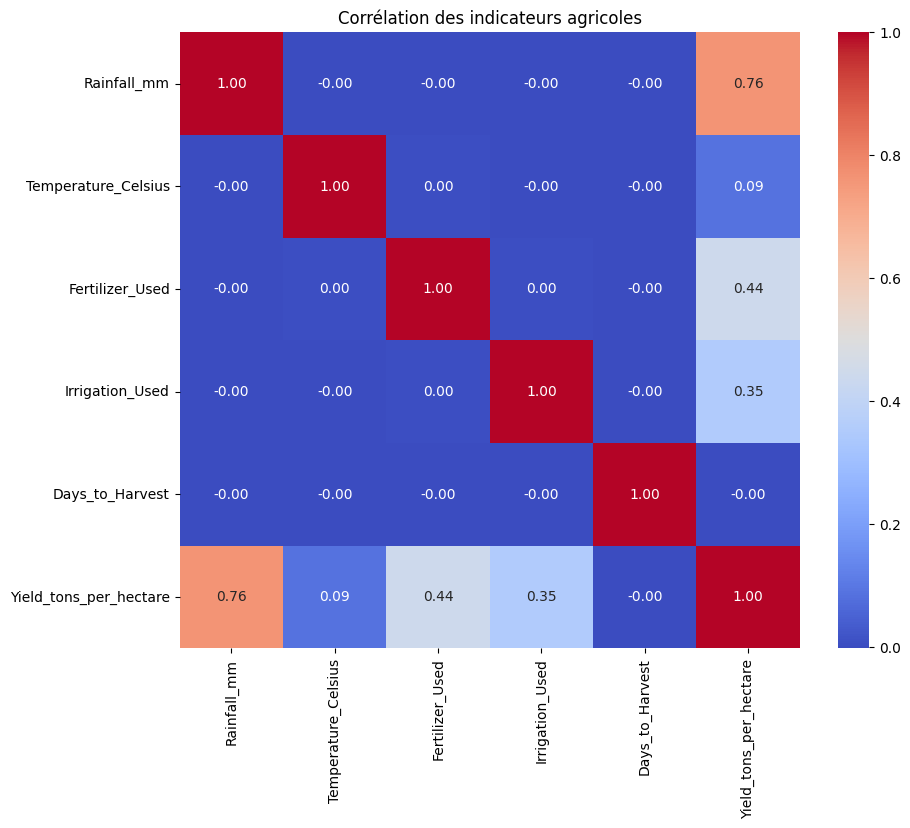

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Corrélation des indicateurs agricoles')
plt.show()

In [26]:
from sklearn.ensemble import RandomForestRegressor

In [27]:
features = ['Rainfall_mm', 'Fertilizer_Used','Temperature_Celsius', 'Irrigation_Used']
X = Agri[features]
y = Agri['Yield_tons_per_hectare']

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Convertir True/False en 1 et 0
Agri['Fertilizer_Used'] = Agri['Fertilizer_Used'].astype(int)
Agri['Irrigation_Used'] = Agri['Irrigation_Used'].astype(int)

In [31]:
Agri_encoded = pd.get_dummies(Agri, columns=['Soil_Type', 'Crop'], drop_first=True)

In [39]:
model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, random_state=42)

In [40]:
y_pred = model.predict(X_test)

In [41]:
from sklearn.metrics import mean_absolute_error

In [42]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [43]:
print(f"--- Évaluation du modèle Agri ---")
print(f"MAE  : {mae:.2f} tonnes")
print(f"RMSE : {rmse:.2f} tonnes")
print(f"R²   : {r2:.2f}")

--- Évaluation du modèle Agri ---
MAE  : 0.39 tonnes
RMSE : 0.49 tonnes
R²   : 0.89


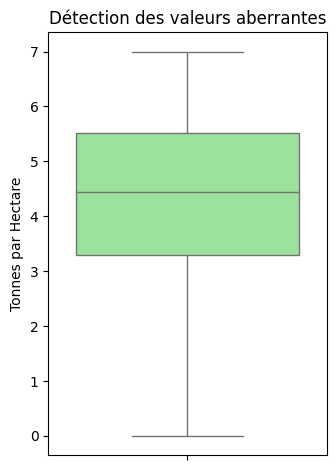

In [44]:
plt.subplot(1, 2, 2)
sns.boxplot(y=Agri['Yield_tons_per_hectare'], color="lightgreen")
plt.title('Détection des valeurs aberrantes')
plt.ylabel('Tonnes par Hectare')

plt.tight_layout()
plt.show()

La Courbe de Validation (Learning Curve)

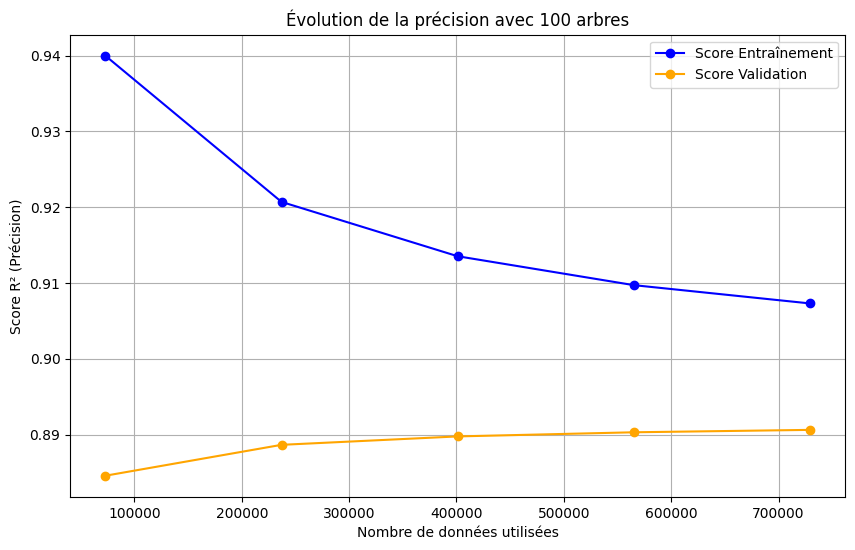

In [48]:
# 1. On définit le modèle avec 100 arbres et profondeur 15
model_100 = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)

# 2. On calcule les scores (Précision R²) pour différentes tailles de données
# train_sizes : les étapes (ex: 1000 lignes, 5000 lignes, etc.)
# train_scores : les notes pendant l'entraînement
# test_scores : les notes sur les données de test (ton 0.87)
train_sizes, train_scores, test_scores = learning_curve(
    model_100, X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# 3. On fait la MOYENNE des scores (car il y a 5 tests par étape)
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# 4. LA VISUALISATION
plt.figure(figsize=(10, 6))

# Ligne bleue : comment le modèle apprend ses leçons
plt.plot(train_sizes, train_mean, label='Score Entraînement', marker='o', color='blue')

# Ligne orange : comment le modèle réussit l'examen final (le plus important)
plt.plot(train_sizes, test_mean, label='Score Validation', marker='o', color='orange')

plt.title('Évolution de la précision avec 100 arbres')
plt.xlabel('Nombre de données utilisées')
plt.ylabel('Score R² (Précision)')
plt.legend()
plt.grid(True)
plt.show()

Le Score d'Entraînement (Bleu) descend : C'est une très bonne chose ! Cela signifie que ton modèle arrête d'apprendre "par cœur" (overfitting) et commence à comprendre les règles générales.

Le Score de Validation (Orange) monte : Il atteint presque 0.89. C'est ta performance réelle.

La convergence : Les deux courbes tendent à se rejoindre. Ton modèle est devenu très stable et honnête.

2. Le diagnostic final
Le "Gap" (l'écart) : Il est maintenant très réduit par rapport à tes premiers essais. Cela prouve que ton nettoyage (enlever les valeurs négatives) et ton encodage ont fonctionné.

Saturation : À partir de 600 000 données, la courbe orange devient presque plate. Cela confirme que pour ce modèle, tu as assez de données. Ajouter 100 Mo de plus ne changerait plus grand-chose.

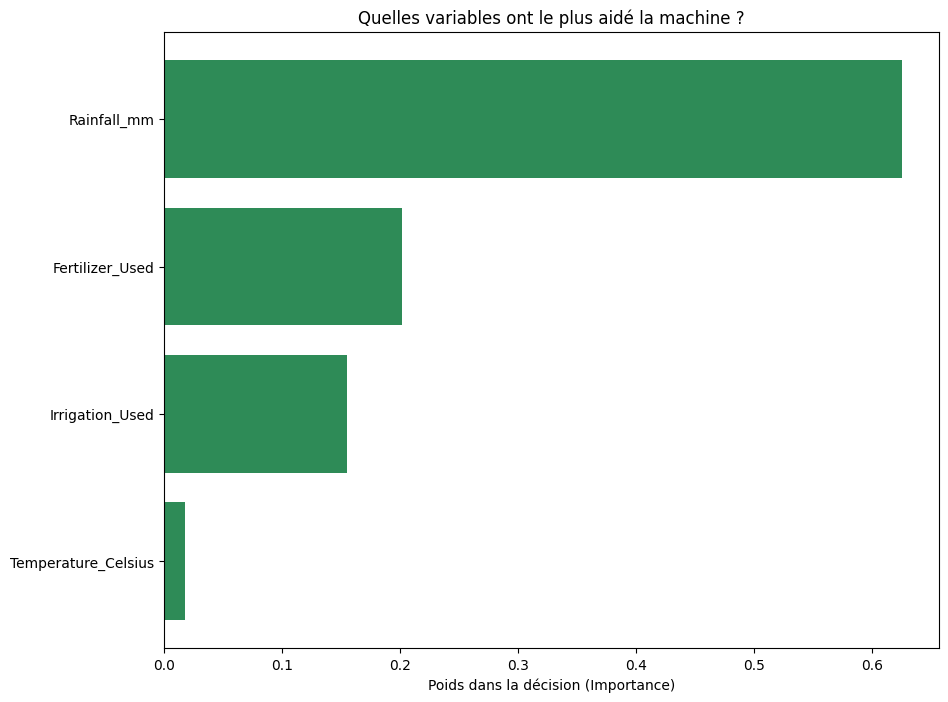

In [49]:
# On récupère les scores d'importance du modèle
importances = model.feature_importances_
features = X.columns

# On trie pour avoir les plus importants en haut
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title('Quelles variables ont le plus aidé la machine ?')
plt.barh(range(len(indices)), importances[indices], color='seagreen', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Poids dans la décision (Importance)')
plt.show()

In [61]:

# 1. On crée une ligne vide (même colonnes, même ordre que l'entraînement)
df_simu = pd.DataFrame(0, index=[0], columns=model.feature_names_in_)
# 2. On remplis UNIQUEMENT ce qu'on veux tester
# (Le reste restera à 0 par défaut)
df_simu['Rainfall_mm'] = 600.0
df_simu['Temperature_Celsius'] = 22.0
df_simu['Fertilizer_Used'] = 1

# La réponse
pred = model.predict(df_simu)

print(f"Résultat : {pred[0]:.2f} t/ha")

Résultat : 4.99 t/ha


importation Hugging face

In [62]:
import joblib

# On sauvegarde le modèle ET la liste des colonnes (très important pour les prédictions futures)
model_data = {
    "model": model,
    "features": model.feature_names_in_.tolist()
}

joblib.dump(model_data, "agri_model.joblib")
print("Modèle sauvegardé dans le fichier : agri_model.joblib")

Modèle sauvegardé dans le fichier : agri_model.joblib
